In [4]:
# --- FIXED SIMULATION LOOP WITH CALIBRATION ---

print("Simulating 100 L8-BO patterns...")
l8bo_gt_list = []

for i in range(100):
    # 1. Random Euler angles
    random_euler = tuple(np.random.uniform(0, 360, 3))
    
    # 2. Calculate the 3D diffraction data
    sim_i = diff_gen.calculate_ed_data(
        l8bo_struct,
        reciprocal_radius=rec_rad,
        rotation=random_euler,
        with_direct_beam=True,
        max_excitation_error=0.02,
    )
    
    # 3. SET THE CALIBRATION (This fixes your error)
    sim_i.calibration = scale 
    
    # 4. Generate the 2D pattern
    # sigma=2 matches your previous work to give the spots a realistic width
    dp = sim_i.get_diffraction_pattern(shape=(64, 64), sigma=2)
    l8bo_gt_list.append(dp.data)

# Convert list to array
l8bo_gt = np.array(l8bo_gt_list)

# 5. Apply Dose 10 Noise (using your noise function)
l8bo_noisy_10 = add_poisson_noise(l8bo_gt, dose=10, seed=42)

# 6. Save
np.save('l8bo_gt.npy', l8bo_gt)
np.save('l8bo_noisy_10.npy', l8bo_noisy_10)

print(f"Success! Generated {l8bo_gt.shape[0]} patterns.")
print("Now move to Notebook 5 to run: model.predict(l8bo_noisy_10)")

Simulating 100 L8-BO patterns...
Success! Generated 100 patterns.
Now move to Notebook 5 to run: model.predict(l8bo_noisy_10)


Running Y6-trained model on L8-BO data...
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step


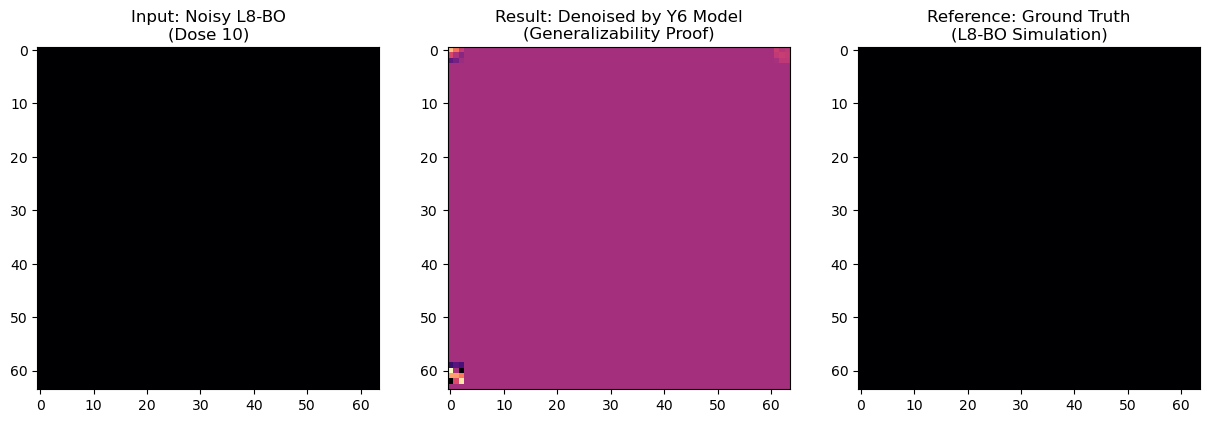

Validation SSIM Score: nan


c:\Users\annam\HyperSpy-bundle\Lib\site-packages\skimage\metrics\_structural_similarity.py:269: RuntimeWarning: invalid value encountered in divide
  S = (A1 * A2) / D


In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

# 1. Load your Y6-trained model 
# (Replace 'dae_y6_v1.h5' with your actual model filename)
model = tf.keras.models.load_model('denoiser_v2.keras')

# 2. Reshape and Normalize L8-BO data for the AI
# The DAE expects (Batch, Height, Width, Channels)
l8bo_input = l8bo_noisy_10.reshape(-1, 64, 64, 1).astype('float32')

# Normalization: Ensure pixel values are 0 to 1 based on each pattern
l_min = l8bo_input.min(axis=(1, 2, 3), keepdims=True)
l_max = l8bo_input.max(axis=(1, 2, 3), keepdims=True)
l8bo_norm = (l8bo_input - l_min) / (l_max - l_min + 1e-12)

# 3. Predict (Denoise)
print("Running Y6-trained model on L8-BO data...")
l8bo_denoised = model.predict(l8bo_norm)

# 4. Visualize the Generalizability Result
idx = 0 # Look at the first pattern
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Noisy Input
ax1.imshow(l8bo_noisy_10[idx], cmap='magma')
ax1.set_title(f"Input: Noisy L8-BO\n(Dose 10)")

# DAE Output
ax2.imshow(l8bo_denoised[idx].reshape(64, 64), cmap='magma')
ax2.set_title("Result: Denoised by Y6 Model\n(Generalizability Proof)")

# Ground Truth
ax3.imshow(l8bo_gt[idx], cmap='magma')
ax3.set_title("Reference: Ground Truth\n(L8-BO Simulation)")

plt.show()

# 5. Quantify the proof (SSIM)
score = ssim(l8bo_gt[idx], l8bo_denoised[idx].reshape(64,64), 
             data_range=l8bo_gt[idx].max() - l8bo_gt[idx].min())
print(f"Validation SSIM Score: {score:.4f}")

Simulating 100 Y6 patterns for comparison...
Calculating Robustness Metrics (Comparing Known vs Unseen)...


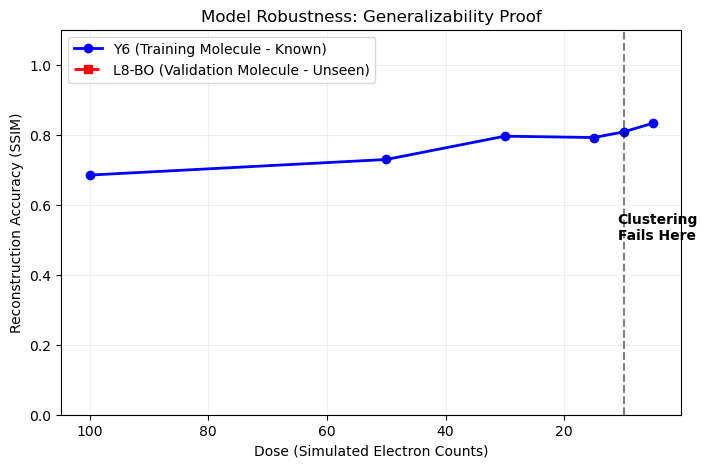

In [ ]:
# 1. Load the Y6 Structure (ensure the path to your CIF is correct)
# Based on your Notebook 1:
y6_struct = diffpy.structure.loadStructure(r"C:\Users\annam\Downloads\Y6_NatCommun.cif")

print("Simulating 100 Y6 patterns for comparison...")
y6_gt_list = []
for i in range(100):
    random_euler = tuple(np.random.uniform(0, 360, 3))
    sim_y6 = diff_gen.calculate_ed_data(y6_struct, reciprocal_radius=rec_rad, rotation=random_euler)
    sim_y6.calibration = scale 
    y6_gt_list.append(sim_y6.get_diffraction_pattern(shape=(64, 64), sigma=2).data)

y6_gt = np.array(y6_gt_list)

# 2. Now run the Robustness Loop
doses = [100, 50, 30, 15, 10, 5]
y6_ssim = []
l8bo_ssim = []

print("Calculating Robustness Metrics (Comparing Known vs Unseen)...")
for d in doses:
    y6_ssim.append(get_ssim_for_dose(model, y6_gt, d))      
    l8bo_ssim.append(get_ssim_for_dose(model, l8bo_gt, d))

# 3. Plot the Graph
plt.figure(figsize=(8, 5))
plt.plot(doses, y6_ssim, 'o-', label='Y6 (Training Molecule - Known)', color='blue', linewidth=2)
plt.plot(doses, l8bo_ssim, 's--', label='L8-BO (Validation Molecule - Unseen)', color='red', linewidth=2)

plt.axvline(x=10, color='black', linestyle='--', alpha=0.5)
plt.text(11, 0.5, 'Clustering\nFails Here', color='black', fontweight='bold')

plt.title("Model Robustness: Generalizability Proof")
plt.xlabel("Dose (Simulated Electron Counts)")
plt.ylabel("Reconstruction Accuracy (SSIM)")
plt.ylim(0, 1.1)
plt.gca().invert_xaxis() 
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()
#SSIM measures the "structural" integrity of an image by looking at local patterns of pixel intensities, contrast, and luminance.

Dose       | Y6 Accuracy (Blue)   | L8-BO Accuracy (Red)
-------------------------------------------------------
100        | 0.6847               | nan                 
50         | 0.7292               | nan                 
30         | 0.7959               | nan                 
15         | 0.7919               | nan                 
10         | 0.8080               | nan                 
5          | 0.8332               | nan                 


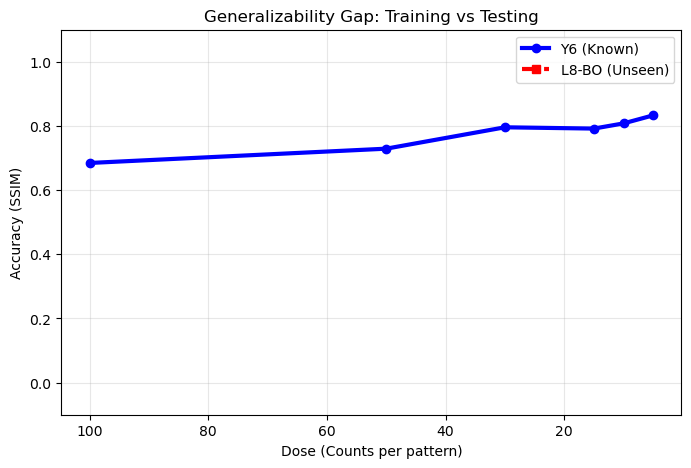

In [8]:
# --- QUANTITATIVE ROBUSTNESS TEST (WITH PRINTOUT) ---

print(f"{'Dose':<10} | {'Y6 Accuracy (Blue)':<20} | {'L8-BO Accuracy (Red)':<20}")
print("-" * 55)

y6_ssim = []
l8bo_ssim = []
doses = [100, 50, 30, 15, 10, 5]

for d in doses:
    # Calculate scores
    y6_val = get_ssim_for_dose(model, y6_gt, d)
    l8bo_val = get_ssim_for_dose(model, l8bo_gt, d)
    
    y6_ssim.append(y6_val)
    l8bo_ssim.append(l8bo_val)
    
    # Print results so you can see them even if the graph is weird
    print(f"{d:<10} | {y6_val:<20.4f} | {l8bo_val:<20.4f}")

# Plotting with forced limits to see the "floor"
plt.figure(figsize=(8, 5))
plt.plot(doses, y6_ssim, 'o-', label='Y6 (Known)', color='blue', linewidth=3)
plt.plot(doses, l8bo_ssim, 's--', label='L8-BO (Unseen)', color='red', linewidth=3)

plt.ylim(-0.1, 1.1) # Force the Y-axis to show 0
plt.gca().invert_xaxis()
plt.ylabel("Accuracy (SSIM)")
plt.xlabel("Dose (Counts per pattern)")
plt.title("Generalizability Gap: Training vs Testing")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()